<a href="https://colab.research.google.com/github/ichika-yay/Economics-Brawl-Stars/blob/main/%E9%82%8A%E9%9A%9B%E6%95%88%E7%94%A8%E7%90%86%E8%AB%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**邦妮和駛徒完成表演後說想吃點心，駛徒於是給了邦妮金幣，邦妮於是蹦蹦跳跳地到蔓蒂的甜品店。**<br>**邦妮帶著駛徒給的金幣到蔓蒂的糖果店買糖果和餅乾吃，他的目標是想要找到最滿意的消費組合，避免任何一個買太多吃膩或買太少吃不夠**

**1.基本資料:** 讓使用者輸入經濟參數

In [1]:
import numpy as np
# 引進數學工具箱numpy，並以np簡稱
print("=====蔓蒂糖果店開張=====")
bonnie_coin = int(input("請輸入駛徒給了邦妮多少金幣 "))
candy_price = int(input("請輸入糖果的價格 "))
cookie_price = int(input("請輸入餅乾的價格 "))
print(f"邦妮的金幣有{bonnie_coin}個")
print(f"糖果售價{candy_price}元")
print(f"餅乾售價{cookie_price}元")
# f代表format 格式化 在引號前加f後用大括號括起變數

=====蔓蒂糖果店開張=====
請輸入駛徒給了邦妮多少金幣 100
請輸入糖果的價格 5
請輸入餅乾的價格 10
邦妮的金幣有100個
糖果售價5元
餅乾售價10元


**2-1.定義效用函數:** 在此處欲滿足邊際效用遞減法則，使用 **偏好權重*ln(財貨數量+1)** 作為效用函數 (因ln是隨著自變數增加而增幅遞減的函數)

In [2]:
def bonnie_u(candy,cookie):
# 定義一個函數 只要輸入括號內的變數 即能return該函數值
 candy_u = 1.5 * np.log(candy+1)
 cookie_u = 1.0 * np.log(cookie+1)
 return candy_u + cookie_u
# 財貨效用=加權(此設邦妮比較喜歡吃糖)*開對數(數量+1)
# ln(1)=0, 對應到吃下0個點心的總效用
print(f"糖果0顆 餅乾0塊:{bonnie_u(0,0):.2f}分")
print(f"糖果1顆 餅乾1塊:{bonnie_u(1,1):.2f}分")
print(f"糖果2顆 餅乾2塊:{bonnie_u(2,2):.2f}分")
print(f"糖果3顆 餅乾3塊:{bonnie_u(3,3):.2f}分")
# 測試邦妮的簡化大腦，效用值取到小數點第二位

糖果0顆 餅乾0塊:0.00分
糖果1顆 餅乾1塊:1.73分
糖果2顆 餅乾2塊:2.75分
糖果3顆 餅乾3塊:3.47分


**2-2.總效用計算:** 讓使用者自行輸入財貨購買量，導出效用值

In [3]:
candy_c = int(input("邦妮買了多少顆糖(暫不考慮預算)"))
cookie_c = int(input("邦妮買了多少塊餅乾(暫不考慮預算)"))
print(f"邦妮獲得的效用值為{bonnie_u(candy_c,cookie_c):.2f}分")

邦妮買了多少顆糖(暫不考慮預算)5
邦妮買了多少塊餅乾(暫不考慮預算)5
邦妮獲得的效用值為4.48分


**3.尋找消費均衡組合(理論):** 透過scipy尋找總效用最大組合 並驗證MU/P是否相等

In [4]:
from scipy.optimize import minimize
# 引進外援工具箱scipy，協助我們尋找最小值
def utility(choices):
  candy,cookie = choices
  return -bonnie_u(candy,cookie)
# 定義一個scipy看得懂的指標
def budget(choices):
  candy,cookie = choices
  spent = (candy * candy_price) + (cookie * cookie_price)
  return bonnie_coin - spent
# 確保邦妮能夠剛剛好的把金幣通通花光一毛不剩(理論版)
con = ({'type':'eq','fun':budget})
# 為接續的演算設下限制 預算必須花光 而用於計算的的函數即為前面的budget
bounds = ((0,None),(0,None))
# 為接續的演算設下上下限：糖果與餅乾兩種自變數 最少不買 且只要預算允許 沒有購買上限
initial_guess = [1,1]
# 為接續的演算設下初始猜測值：在(1,1)出發尋找最大值
result = minimize(utility,initial_guess,bounds=bounds,constraints=con)
best_candy,best_cookie = result.x
# 將最小組合的自變數組合塞進新宣告的變數
candy_mu = 1.5 / (best_candy+1)
cookie_mu = 1.0 / (best_cookie+1)
# 邊際效用 = 效用函數微分
candy_mu_price = candy_mu / candy_price
cookie_mu_price = cookie_mu / cookie_price
# 邊際效用/價格 每1元的錢帶來的效用理應要相等
print("=====邦妮的黃金消費均衡組合=====")
print(f"邦妮應該買{best_candy:.2f}顆糖果")
print(f"邦妮應該買{best_cookie:.2f}塊餅乾")
print(f"邦妮總共花了{candy_price*best_candy+cookie_price*best_cookie:.2f}元")
print(f"邦妮獲得的效用值為{-result.fun:.4f}分")
print("================================")
print("驗證最後1元的邊際效用是否相等?")
print(f"邦妮花在糖果上的最後1元效用值為{candy_mu_price:.4f}分")
print(f"邦妮花在餅乾上的最後1元效用值為{cookie_mu_price:.4f}分")


=====邦妮的黃金消費均衡組合=====
邦妮應該買12.80顆糖果
邦妮應該買3.60塊餅乾
邦妮總共花了100.00元
邦妮獲得的效用值為5.4631分
驗證最後1元的邊際效用是否相等?
邦妮花在糖果上的最後1元效用值為0.0217分
邦妮花在餅乾上的最後1元效用值為0.0217分


**3.尋找消費均衡組合(現實):** 由於現實中財貨不可分割，需要代入所有可能消費組合求最大效用值

In [5]:
max_u = -1
rbest_candy = 0
rbest_cookie = 0
# 在電腦裡準備三個空格，用來記錄最高效用分&最適購買量
# -1是最初假設（效用不會變負數所以一定會被蓋掉）
max_candy = bonnie_coin // candy_price
# 現有金幣最多能買幾顆糖果（//：求商數）
for candy in range(max_candy + 1):
# 把串列中的每個糖果可能值拿出來測試
# range(x)不會包括終止值x，需要在括號內+1
  remain_coin = bonnie_coin - (candy * candy_price)
  max_cookie = remain_coin // cookie_price
  for cookie in range(max_cookie + 1):
    total_cost = (candy * candy_price) + (cookie * cookie_price)
    if total_cost <= bonnie_coin:
      cur_u = bonnie_u(candy,cookie)
      if cur_u > max_u:
        max_u = cur_u
        rbest_candy = candy
        rbest_cookie = cookie
print("=====邦妮在現實中的黃金消費組合=====")
print(f"邦妮應該買{rbest_candy}顆糖果")
print(f"邦妮應該買{rbest_cookie}塊餅乾")
print(f"邦妮總共花了{rbest_candy*candy_price+rbest_cookie*cookie_price}元")
print(f"邦妮獲得的效用值為{max_u:.4f}分")

=====邦妮在現實中的黃金消費組合=====
邦妮應該買12顆糖果
邦妮應該買4塊餅乾
邦妮總共花了100元
邦妮獲得的效用值為5.4569分


**4.繪製理想&現實組合的差距圖**

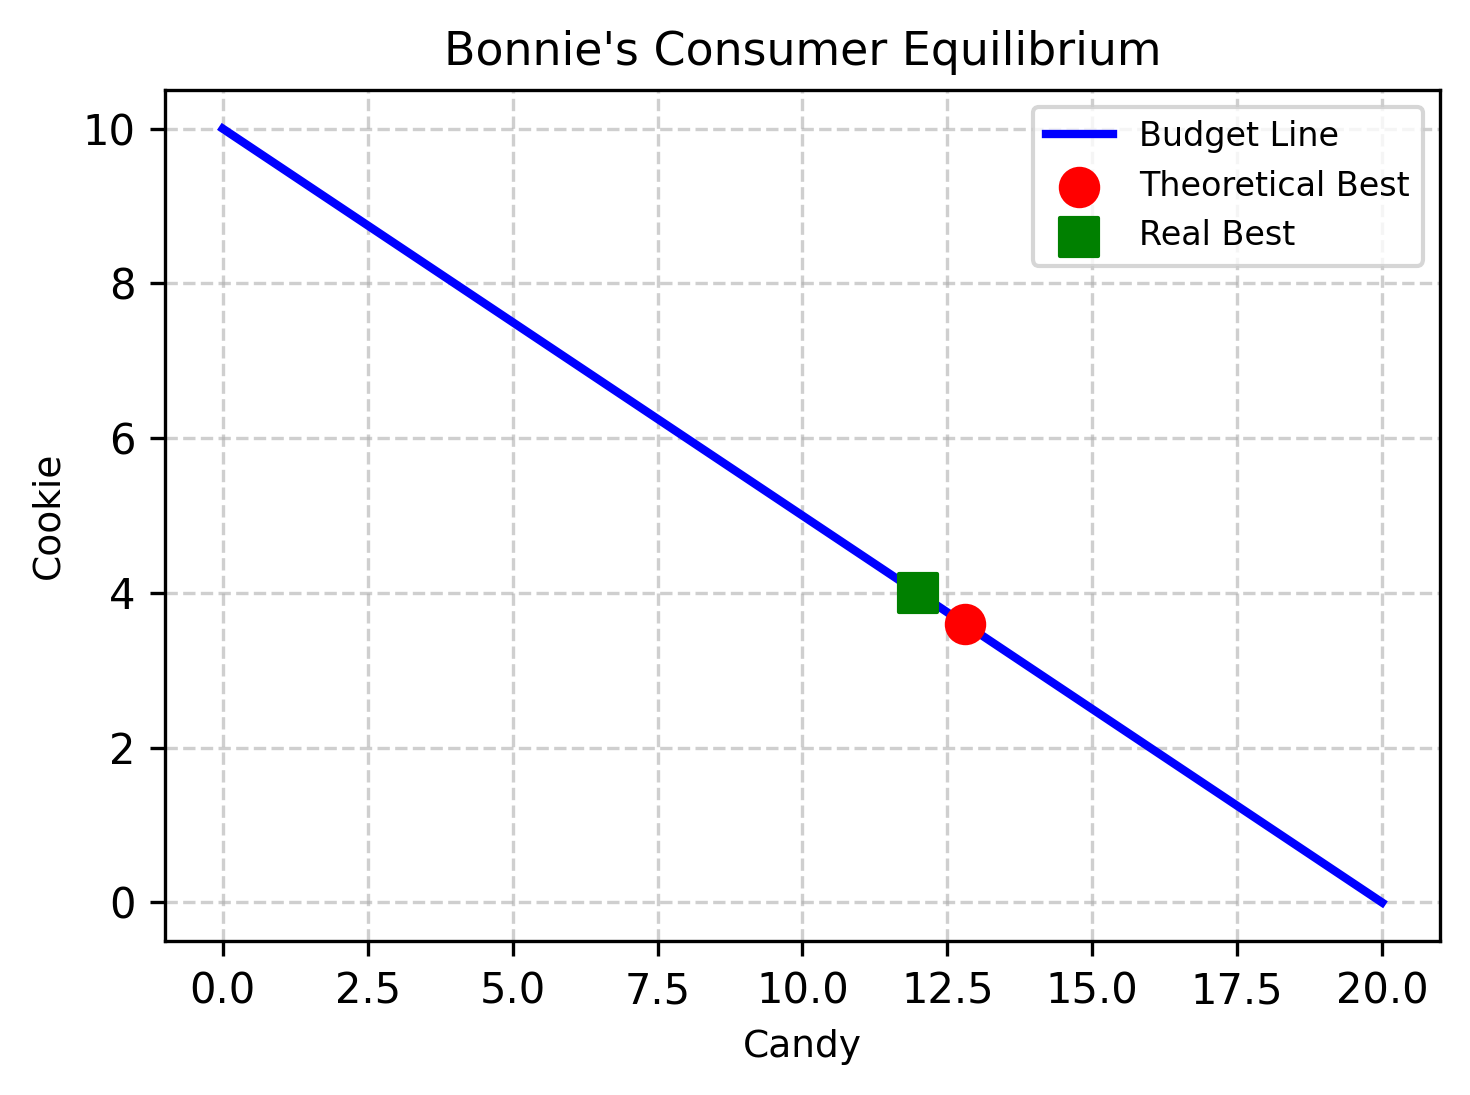

In [6]:
import matplotlib.pyplot as plt
# 引進python內建的彩色畫筆組
candy_axis = np.linspace(0,bonnie_coin/candy_price,100)
# 設定橫軸值：糖果的購買數量
# 項數的值決定了線的平滑程度，通常輸入100夠順滑 電腦也比較好運作
cookie_axis = (bonnie_coin-candy_axis*candy_price)/cookie_price
plt.figure(figsize=(5,3.75),dpi=300,facecolor="white")
# 設定畫布：長寬 5x3.75 英吋 解析度300 背景白
plt.plot(candy_axis,cookie_axis,label="Budget Line",linewidth=2,color="blue")
# 畫線：（x座標資料,y座標資料,額外資料）
plt.scatter(best_candy,best_cookie,color="red",label="Theoretical Best",s=80,zorder=5)
# 畫點：標出理論上的MU/P相等均衡解
plt.scatter(rbest_candy,rbest_cookie,color="green",label="Real Best",s=80,zorder=5,marker="s")
# 畫點：標出現實中的總效益最大解（以正方形區分）
plt.title("Bonnie\'s Consumer Equilibrium",fontsize=11)
plt.xlabel("Candy",fontsize=9)
plt.ylabel("Cookie",fontsize=9)
plt.grid(True,linestyle="--",alpha=0.6)
# True為讓格子顯示，False為隱藏
plt.legend(fontsize=8)
# 畫一個圖例說明框
plt.tight_layout()
plt.show()